В этой части модуля мы будем работать с популярным датасетом MovieLens, в котором собраны логи некоторой рекомендательной системы фильмов.

*Наши данные представляют собой четыре таблицы:*

```ratings1 и ratings2``` — таблицы с данными о выставленных пользователями оценках фильмов. Они имеют одинаковую структуру и типы данных — на самом деле это две части одной таблицы с оценками фильмов.

* userId — уникальный идентификатор пользователя, который выставил оценку;
* movieId — уникальный идентификатор фильма;
* rating — рейтинг фильма.

```dates``` — таблица с датами выставления всех оценок

* date — дата и время выставления оценки фильму.

```movies``` — таблица с информацией о фильмах

* movieId — уникальный идентификатор фильма;
* title — название фильма и год его выхода;
* genres — жанры фильма.

Нам надо получить единую таблицу, в которой будут собраны рейтинги, даты выставления рейтингов, а также информация о фильмах. Вот как мы будем действовать:

* 1
Склеим таблицы ```ratings1``` и ```ratings2``` в единую структуру.

* 2
К полученной таблице с рейтингами подсоединим столбец с датой проставления рейтинга, склеив столбцы таблиц между собой.

* 3
Присоединим к нашей таблице информацию о названиях и жанрах фильмов.

In [43]:
import pandas as pd

In [44]:
movies = pd.read_csv('data/movies.csv', sep=',')
display(movies['title'].value_counts().nunique)

<bound method IndexOpsMixin.nunique of title
Emma (1996)                                  2
Saturn 3 (1980)                              2
Confessions of a Dangerous Mind (2002)       2
Eros (2004)                                  2
War of the Worlds (2005)                     2
                                            ..
Black Butler: Book of the Atlantic (2017)    1
No Game No Life: Zero (2017)                 1
Flint (2017)                                 1
Bungo Stray Dogs: Dead Apple (2018)          1
Andrew Dice Clay: Dice Rules (1991)          1
Name: count, Length: 9737, dtype: int64>

In [45]:
ratings1 = pd.read_csv('data/ratings1.csv', sep=',')
display(ratings1['userId'].value_counts().nunique)

<bound method IndexOpsMixin.nunique of userId
68     1260
249    1046
182     977
177     904
232     862
       ... 
147      20
189      20
194      20
207      20
257      20
Name: count, Length: 274, dtype: int64>

In [49]:
ratings2 = pd.read_csv('data/ratings2.csv', sep=',')
display(ratings2)

,userId,movieId,rating
0,274,5621,2.0
1,274,5630,3.0
2,274,5667,3.5
3,274,5679,3.5
4,274,5690,3.0
...,...,...,...
60831,610,166534,4.0
60832,610,168248,5.0
60833,610,168250,5.0
60834,610,168252,5.0


In [46]:
dates = pd.read_csv('data/dates.csv', sep=',')
print(dates['date'].mode())

0    2016-04-04 16:39:58
Name: date, dtype: str


# Объединение DataFrame: concat

Первым делом мы должны склеить таблицы ```ratings1 и ratings2``` по строкам.

Для этого воспользуемся встроенной функцией Pandas ```concat()```, которая позволяет склеивать (конкатенировать) таблицы как по строкам, так и по столбцам.

## Основные параметры функции ```concat()```

* ```objs``` — список объектов DataFrame ([df1, df2,…]), которые должны быть сконкатенированы;
* ```axis``` — ось определяет направление конкатенации: 0 — конкатенация по строкам (по умолчанию), 1 — конкатенация по столбцам;
* ```join``` — либо ```inner``` (пересечение), либо outer (объединение); рассмотрим этот момент немного позже;
* ```ignore_index``` — по умолчанию установлено значение False, которое позволяет значениям индекса оставаться такими, какими они были в исходных данных. Если установлено значение True, параметр будет игнорировать исходные значения и повторно назначать значения индекса в последовательном порядке.

** Для корректной конкатенации по строкам объединяемые таблицы должны иметь одинаковую структуру — идентичное число и имена столбцов. ** 

*Примечание. Обратите внимание, что concat является функцией библиотеки, а не методом DataFrame. Поэтому её вызов осуществляется как ```pd.concat(...).```*

In [51]:
ratings = pd.read_csv('data/ratings1.csv', sep=',')
display(ratings1)

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
39996,274,5582,2.5
39997,274,5585,3.5
39998,274,5588,3.5
39999,274,5618,4.0


In [52]:
ratings2 = pd.read_csv('data/ratings2.csv', sep=',')
display(ratings2)

,userId,movieId,rating
0,274,5621,2.0
1,274,5630,3.0
2,274,5667,3.5
3,274,5679,3.5
4,274,5690,3.0
...,...,...,...
60831,610,166534,4.0
60832,610,168248,5.0
60833,610,168250,5.0
60834,610,168252,5.0


In [50]:
ratings = pd.concat([ratings1, ratings2])
display(ratings)

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
60831,610,166534,4.0
60832,610,168248,5.0
60833,610,168250,5.0
60834,610,168252,5.0


В результате мы увеличили первую таблицу, добавив снизу строки второй таблицы

На первый взгляд может показаться, что всё прошло успешно, однако если мы посмотрим на индексы последних строк таблицы, то увидим, что их нумерация не совпадает с количеством строк. Это может привести к некорректному объединению таблиц по ключевым столбцам на следующем этапе решения нашей задачи.

Это связано с тем, что по умолчанию concat сохраняет первоначальные индексы объединяемых таблиц, а обе наши таблицы индексировались, начиная от 0. Чтобы создать новые индексы, нужно выставить параметр ignore_index на True:

In [53]:
ratings = pd.concat(
    [ratings1, ratings2],
    ignore_index=True
)
display(ratings)

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
100832,610,166534,4.0
100833,610,168248,5.0
100834,610,168250,5.0
100835,610,168252,5.0


Казалось бы, совсем другое дело! Но это ещё не всё. Давайте узнаем количество строк в таблицах ratings и dates, ведь нам предстоит вертикально склеить их между собой:

In [54]:
print('Число строк в таблице ratings: ', ratings.shape[0])
print('Число строк в таблице dates: ', dates.shape[0])
print(ratings.shape[0] == dates.shape[0])

Число строк в таблице ratings:  100837
Число строк в таблице dates:  100836
False


Размерность таблиц разная — как такое могло произойти?

На самом деле очень просто: при выгрузке данных информация об оценках какого-то  пользователя попала в обе таблицы (ratings1 и ratings2). В результате конкатенации случилось дублирование строк. В данном примере их легко найти — выведем последнюю строку таблицы ratings1 и первую строку таблицы ratings2:

In [55]:
display(ratings1.tail(1))
display(ratings2.head(1))

,userId,movieId,rating
40000,274,5621,2.0


,userId,movieId,rating
0,274,5621,2.0


Чтобы очистить таблицу от дублей, мы можем воспользоваться методом DataFrame ```drop_duplicates()```, который удаляет повторяющиеся строки в таблице. Не забываем обновить индексы после удаления дублей, выставив параметр ```ignore_index``` в методе ```drop_duplicates()``` на значение ```True```:

In [56]:
ratings = ratings.drop_duplicates(ignore_index=True)
print('Число строк в таблице ratings: ', ratings.shape[0])

Число строк в таблице ratings:  100836


Наконец, мы можем добавить к нашей таблице с оценками даты их выставления. Для этого конкатенируем таблицы ratings и dates по столбцам:

In [57]:
ratings_dates = pd.concat([ratings, dates], axis=1)
display(ratings_dates.tail(7))

,userId,movieId,rating,date
100829,610,164179,5.0,2017-05-03 21:07:11
100830,610,166528,4.0,2017-05-04 06:29:25
100831,610,166534,4.0,2017-05-03 21:53:22
100832,610,168248,5.0,2017-05-03 22:21:31
100833,610,168250,5.0,2017-05-08 19:50:47
100834,610,168252,5.0,2017-05-03 21:19:12
100835,610,170875,3.0,2017-05-03 21:20:15


***Задание 6.3 (External resource)***

В ваше распоряжение предоставлена директория users ('./Root/users'). В данной директории содержатся csv-файлы, в каждом из которых хранится информация об идентификаторах пользователей (user_id) и ссылках на их фотографии (image_url). Количество файлов в директории может быть любым.

Вам необходимо написать функцию concat_user_files(path), параметром которой является path — путь до директории.

Функция должна:

Объединить информацию из всех csv-файлов в единый DataFrame.

Удалить дубликаты.

Обновить индексы результирующей таблицы.

Отсортировать пользователей по числовой части user_id (игнорируя буквенную часть).

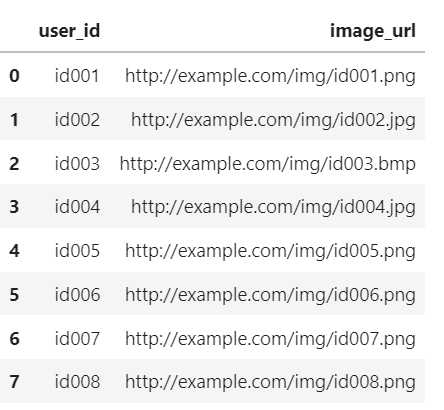

In [ ]:
def concat_user_files(path):
    
    link = path + '/user_id.csv'
    user_id = pd.read_csv(link, sep=',')
    image_url = pd.read_csv('https://example.com/img/image_url.csv')
    
    concat_user_f = pd.concat(
    [user_id, image_url],
    ignore_index=True
)
    
    concat_user_f = concat_user_f.drop_duplicates(ignore_index=True)
    
    concat_user_f.sort_values(by='user_id')
    
    return concat_user_f

path = './Root/users'
concat_user_files(path)

хер пойми какое эталонное решение. в жизнь бы не решил

In [ ]:
import pandas as pd
import os
def concat_user_files(path):
    data = pd.DataFrame()
    file_names = os.listdir(path)
    file_names.sort()
    for file in file_names:
        tmp_data = pd.read_csv(path + '/' + file)
        data = pd.concat([data, tmp_data], axis=0, ignore_index=True)
    data = data.drop_duplicates()
    return data     